# EDA — IMDB Sentiment Dataset
Visualizing the preprocessing pipeline from raw text to TF-IDF feature matrix.

## 0. Imports and Setup

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from scipy.sparse import load_npz
from sklearn.decomposition import TruncatedSVD
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

# Paths
PROCESSED_DIR = Path("../data/processed")

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

print("Imports OK")


Imports OK


## 1. Load Processed Data

In [2]:
# Load TF-IDF matrices
X_train = load_npz(PROCESSED_DIR / "train_tfidf.npz")
X_test  = load_npz(PROCESSED_DIR / "test_tfidf.npz")

# Load labels
y_train = np.load(PROCESSED_DIR / "train_labels.npy")
y_test  = np.load(PROCESSED_DIR / "test_labels.npy")

# Load cleaned texts
with open(PROCESSED_DIR / "train_cleaned.pkl", "rb") as f:
    train_cleaned = pickle.load(f)

# Load vectorizer
with open(PROCESSED_DIR / "vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

feature_names = vectorizer.get_feature_names_out()

print(f"Train matrix : {X_train.shape}")
print(f"Test matrix  : {X_test.shape}")
print(f"Train labels : {y_train.shape}  | unique: {np.unique(y_train)}")
print(f"Vocabulary   : {len(feature_names):,} features")


Train matrix : (25000, 20000)
Test matrix  : (25000, 20000)
Train labels : (25000,)  | unique: [0 1]
Vocabulary   : 20,000 features


## 2. Dataset Overview — Class Balance

Split        Positive   Negative   Total
Train        12,500     12,500     25,000
Test         12,500     12,500     25,000


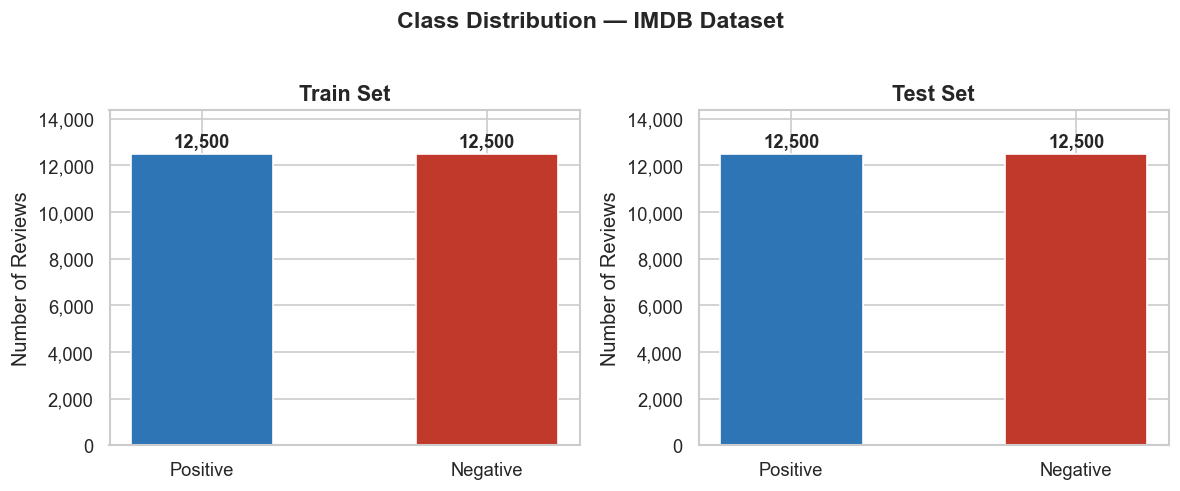

In [3]:
train_pos = int((y_train == 1).sum())
train_neg = int((y_train == 0).sum())
test_pos  = int((y_test  == 1).sum())
test_neg  = int((y_test  == 0).sum())

print("Split        Positive   Negative   Total")
print(f"Train        {train_pos:,}     {train_neg:,}     {len(y_train):,}")
print(f"Test         {test_pos:,}     {test_neg:,}     {len(y_test):,}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, split, pos, neg in zip(
    axes,
    ["Train", "Test"],
    [train_pos, test_pos],
    [train_neg, test_neg]
):
    bars = ax.bar(["Positive", "Negative"], [pos, neg],
                  color=["#2E75B6", "#C0392B"], width=0.5, edgecolor="white")
    for bar, val in zip(bars, [pos, neg]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 100, f"{val:,}",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_title(f"{split} Set", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Reviews")
    ax.set_ylim(0, max(pos, neg) * 1.15)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Class Distribution — IMDB Dataset", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/01_class_balance.png", bbox_inches="tight")
plt.show()


## 3. Raw Review vs Cleaned Review

In [4]:
# Load one raw review directly from disk to show HTML tags
raw_path = Path("../data/raw/aclImdb/train/neg")
raw_files = list(raw_path.glob("*.txt"))
raw_sample = raw_files[0].read_text(encoding="utf-8")
cleaned_sample = train_cleaned[0]

print("RAW REVIEW (first 400 chars):")
print("-" * 60)
print(raw_sample[:400])
print()
print("CLEANED REVIEW (first 400 chars):")
print("-" * 60)
print(cleaned_sample[:400])


RAW REVIEW (first 400 chars):
------------------------------------------------------------
Working with one of the best Shakespeare sources, this film manages to be creditable to it's source, whilst still appealing to a wider audience.<br /><br />Branagh steals the film from under Fishburne's nose, and there's a talented cast on good form.

CLEANED REVIEW (first 400 chars):
------------------------------------------------------------
working one best shakespeare sources film manages creditable source whilst still appealing wider audiencebranagh steals film fishburnes nose theres talented cast good form


## 4. Review Length Distribution

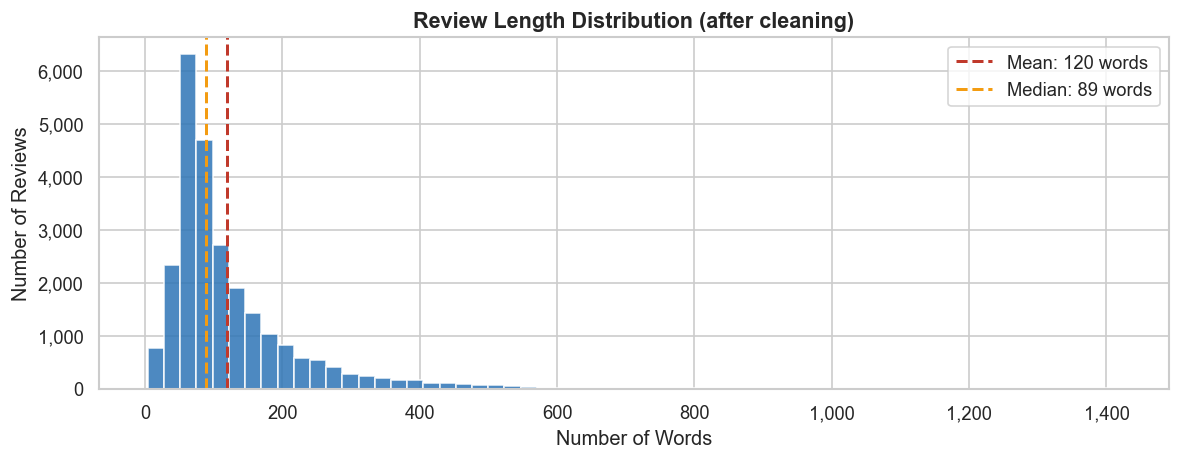

Min length  : 4 words
Max length  : 1420 words
Mean length : 119.9 words
Median      : 89.0 words


In [5]:
lengths = [len(review.split()) for review in train_cleaned]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=60, color="#2E75B6", edgecolor="white", alpha=0.85)
ax.axvline(np.mean(lengths), color="#C0392B", linestyle="--",
           linewidth=1.8, label=f"Mean: {np.mean(lengths):.0f} words")
ax.axvline(np.median(lengths), color="#F39C12", linestyle="--",
           linewidth=1.8, label=f"Median: {np.median(lengths):.0f} words")
ax.set_title("Review Length Distribution (after cleaning)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Words")
ax.set_ylabel("Number of Reviews")
ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../results/figures/02_review_lengths.png", bbox_inches="tight")
plt.show()

print(f"Min length  : {min(lengths)} words")
print(f"Max length  : {max(lengths)} words")
print(f"Mean length : {np.mean(lengths):.1f} words")
print(f"Median      : {np.median(lengths):.1f} words")


## 5. Top 20 Most Frequent Words

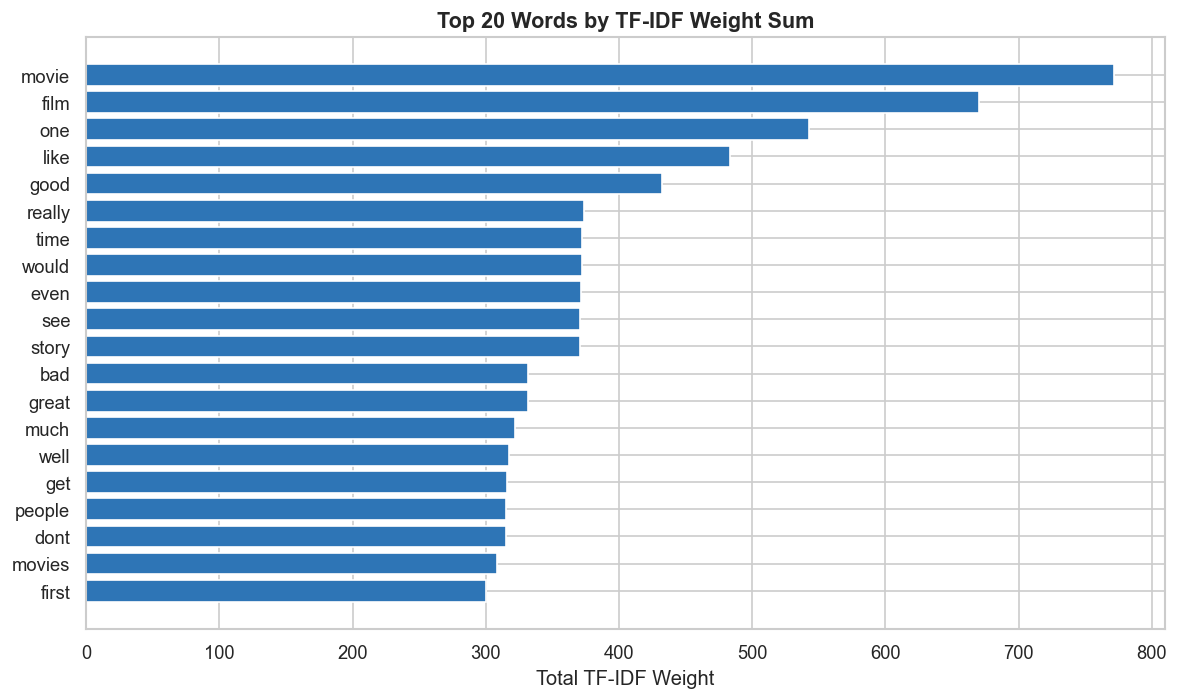

In [6]:
# Sum TF-IDF weights across all documents per feature
tfidf_sums = np.asarray(X_train.sum(axis=0)).flatten()
top_indices = tfidf_sums.argsort()[::-1][:20]
top_words   = [feature_names[i] for i in top_indices]
top_scores  = [tfidf_sums[i] for i in top_indices]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_words[::-1], top_scores[::-1],
               color="#2E75B6", edgecolor="white")
ax.set_title("Top 20 Words by TF-IDF Weight Sum", fontsize=13, fontweight="bold")
ax.set_xlabel("Total TF-IDF Weight")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../results/figures/03_top_words.png", bbox_inches="tight")
plt.show()


## 6. Word Clouds — Positive vs Negative

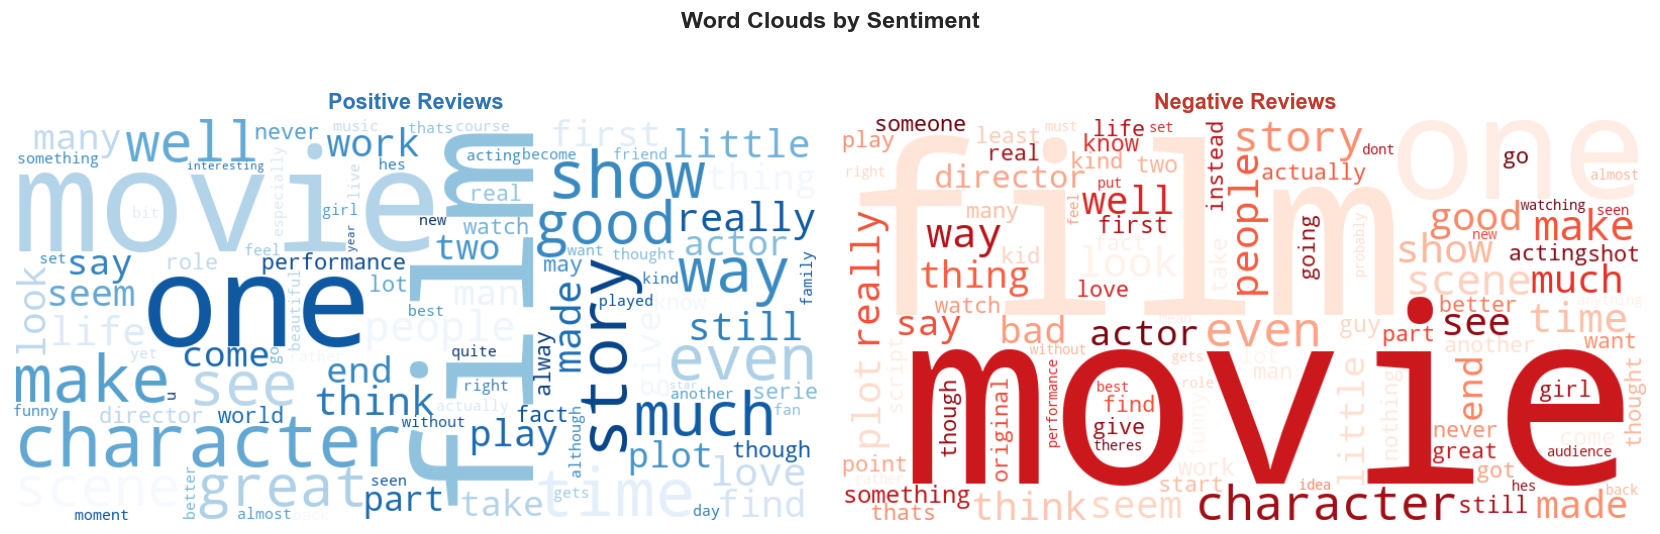

In [7]:
pos_text = " ".join([r for r, l in zip(train_cleaned, y_train) if l == 1])
neg_text = " ".join([r for r, l in zip(train_cleaned, y_train) if l == 0])

wc_pos = WordCloud(width=800, height=400, background_color="white",
                   colormap="Blues", max_words=100).generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color="white",
                   colormap="Reds", max_words=100).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].set_title("Positive Reviews", fontsize=13, fontweight="bold", color="#2E75B6")
axes[0].axis("off")

axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].set_title("Negative Reviews", fontsize=13, fontweight="bold", color="#C0392B")
axes[1].axis("off")

plt.suptitle("Word Clouds by Sentiment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/04_wordclouds.png", bbox_inches="tight")
plt.show()


## 7. TF-IDF Feature Matrix Summary

In [8]:
n_docs, n_features = X_train.shape
nnz      = X_train.nnz
total    = n_docs * n_features
sparsity = 1 - (nnz / total)

print("TF-IDF Feature Matrix Summary")
print("=" * 40)
print(f"Documents (train)  : {n_docs:,}")
print(f"Features           : {n_features:,}")
print(f"Matrix shape       : {X_train.shape}")
print(f"Non-zero entries   : {nnz:,}")
print(f"Sparsity           : {sparsity:.2%}")
print(f"Representation     : Sparse Matrix (CSR)")


TF-IDF Feature Matrix Summary
Documents (train)  : 25,000
Features           : 20,000
Matrix shape       : (25000, 20000)
Non-zero entries   : 2,575,412
Sparsity           : 99.48%
Representation     : Sparse Matrix (CSR)


## 8. Example TF-IDF Vector for One Review

In [14]:
# Select a review
review_idx = 0
review_vec = X_train[review_idx]

# Get indices and TF-IDF values directly
indices = review_vec.indices
weights = review_vec.data

# Sort by TF-IDF weight
sorted_idx = weights.argsort()[::-1][:10]

print("Review text (cleaned):")
print(train_cleaned[review_idx][:200])

print("\nTop TF-IDF features for this review\n")

for i in sorted_idx:
    word = feature_names[indices[i]]
    weight = weights[i]
    print(f"{word:<20} {weight:.3f}")

Review text (cleaned):
working one best shakespeare sources film manages creditable source whilst still appealing wider audiencebranagh steals film fishburnes nose theres talented cast good form

Top TF-IDF features for this review

film manages         0.316
talented cast        0.303
sources              0.285
wider                0.282
cast good            0.272
nose                 0.249
shakespeare          0.242
source               0.231
appealing            0.228
steals               0.228


## 9. Feature Space Visualization — SVD to 2D

Running TruncatedSVD (this may take ~30 seconds)...


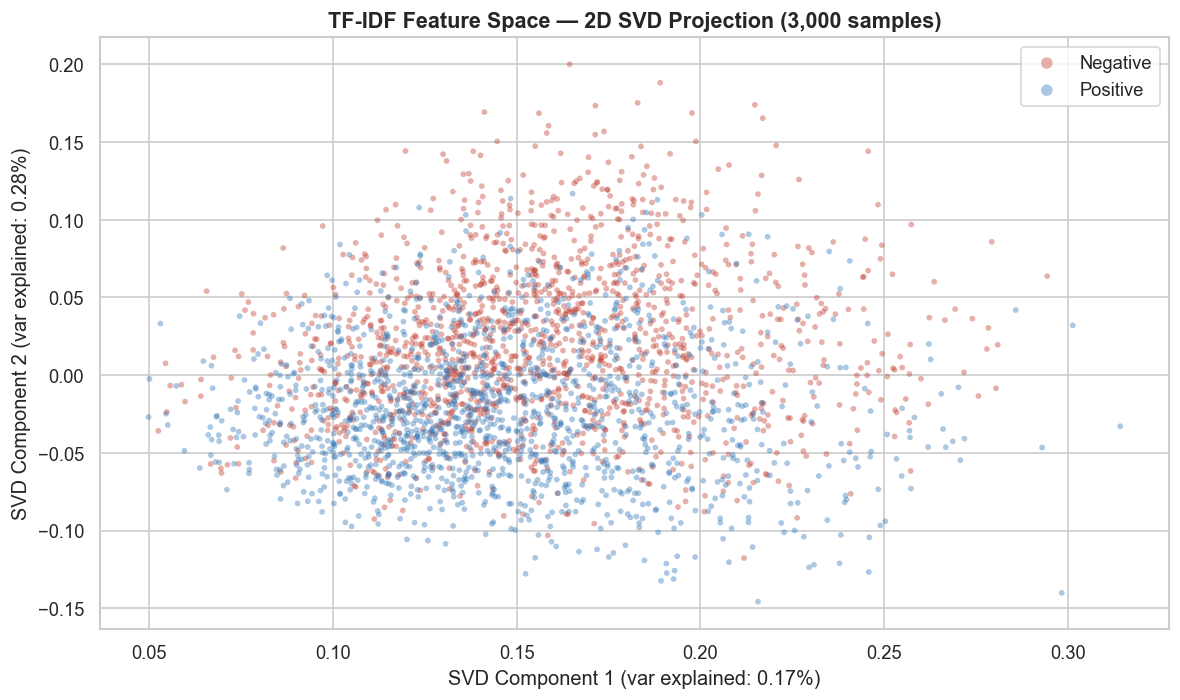

Total variance explained by 2 components: 0.45%


In [16]:
print("Running TruncatedSVD (this may take ~30 seconds)...")
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_train)

sample_idx = np.random.choice(len(y_train), size=3000, replace=False)
X_sample   = X_2d[sample_idx]
y_sample   = y_train[sample_idx]

fig, ax = plt.subplots(figsize=(10, 6))
for label, color, name in zip([0, 1], ["#C0392B", "#2E75B6"], ["Negative", "Positive"]):
    mask = y_sample == label
    ax.scatter(X_sample[mask, 0], X_sample[mask, 1],
               c=color, label=name, alpha=0.4, s=12, edgecolors="none")

ax.set_title("TF-IDF Feature Space — 2D SVD Projection (3,000 samples)",
             fontsize=13, fontweight="bold")
ax.set_xlabel(f"SVD Component 1 (var explained: {svd.explained_variance_ratio_[0]:.2%})")
ax.set_ylabel(f"SVD Component 2 (var explained: {svd.explained_variance_ratio_[1]:.2%})")
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig("../results/figures/05_svd_scatter.png", bbox_inches="tight")
plt.show()

print(f"Total variance explained by 2 components: {svd.explained_variance_ratio_.sum():.2%}")


Running TruncatedSVD to 100 components...
Total variance explained by 100 SVD components: 7.41%
Running t-SNE on 3,000 sampled reviews...


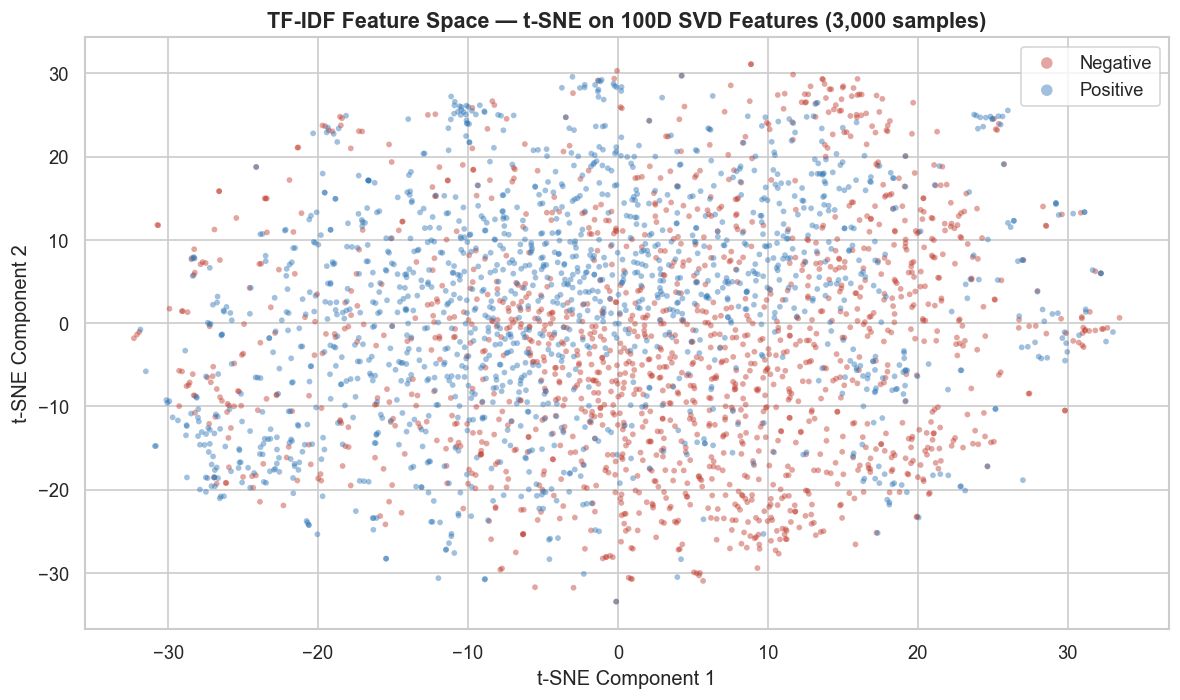

In [17]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

print("Running TruncatedSVD to 100 components...")
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_train)

print(f"Total variance explained by 100 SVD components: {svd.explained_variance_ratio_.sum():.2%}")

# Sample after SVD for faster t-SNE
sample_idx = np.random.choice(len(y_train), size=3000, replace=False)
X_sample = X_svd[sample_idx]
y_sample = y_train[sample_idx]

print("Running t-SNE on 3,000 sampled reviews...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)
X_2d = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(10, 6))

for label, color, name in zip([0, 1], ["#C0392B", "#2E75B6"], ["Negative", "Positive"]):
    mask = y_sample == label
    ax.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=color,
        label=name,
        alpha=0.45,
        s=12,
        edgecolors="none"
    )

ax.set_title("TF-IDF Feature Space — t-SNE on 100D SVD Features (3,000 samples)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig("../results/figures/05_tsne_after_svd.png", bbox_inches="tight")
plt.show()

Total variance explained by 300 SVD components: 15.88%


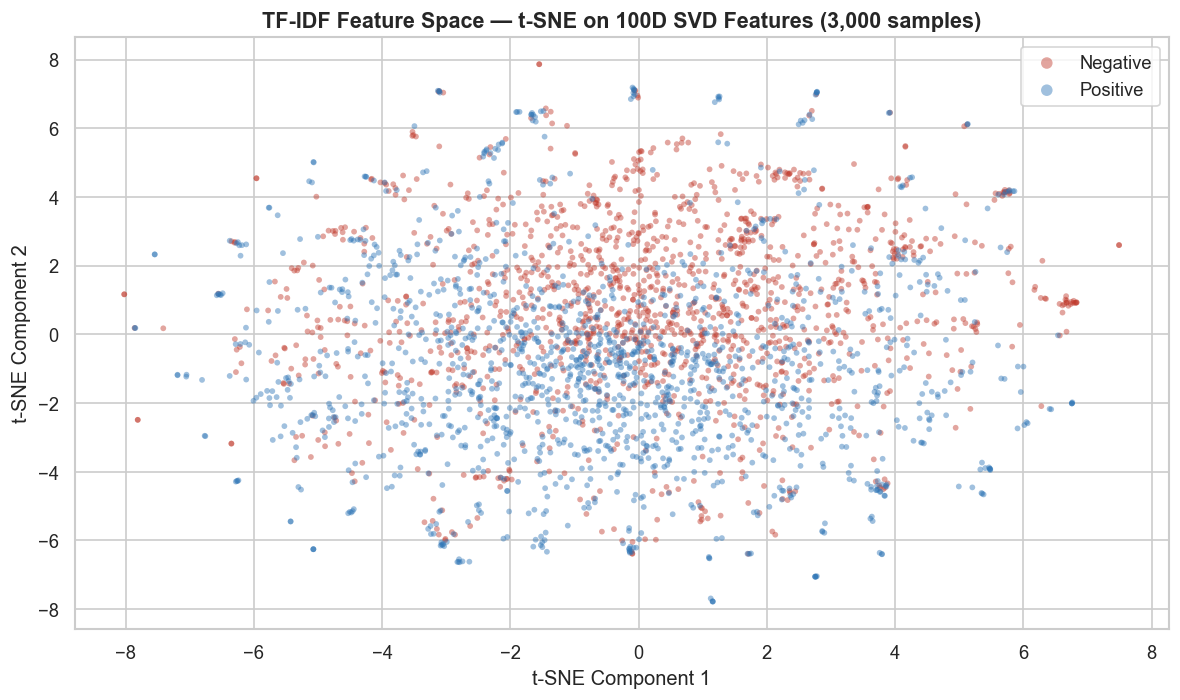

In [19]:
svd = TruncatedSVD(n_components=300, random_state=42)
X_svd = svd.fit_transform(X_train)

print(f"Total variance explained by 300 SVD components: {svd.explained_variance_ratio_.sum():.2%}")

sample_idx = np.random.choice(len(y_train), size=3000, replace=False)
X_sample = X_svd[sample_idx]
y_sample = y_train[sample_idx]

tsne = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1500,
    init="pca",
    learning_rate="auto",
    random_state=42
)

X_2d = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(10, 6))

for label, color, name in zip([0, 1], ["#C0392B", "#2E75B6"], ["Negative", "Positive"]):
    mask = y_sample == label
    ax.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=color,
        label=name,
        alpha=0.45,
        s=12,
        edgecolors="none"
    )

ax.set_title("TF-IDF Feature Space — t-SNE on 100D SVD Features (3,000 samples)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig("../results/figures/05_tsne_after_svd.png", bbox_inches="tight")
plt.show()

## 10. Preprocessing Pipeline Summary

In [15]:
steps = [
    ("Raw IMDB Reviews",          f"50,000 text files (25K train, 25K test)"),
    ("HTML Tag Removal",          "Stripped <br /> and other HTML markup"),
    ("Lowercasing",               "All text converted to lowercase"),
    ("Punctuation Removal",       "Removed non-alphabetic characters"),
    ("Tokenization",              "Split text into individual word tokens"),
    ("Stopword Removal",          "Removed common English stopwords (NLTK)"),
    ("TF-IDF Vectorization",      "max_features=20,000 | ngram_range=(1,2) | min_df=3"),
    ("Feature Matrix",            f"Shape: {X_train.shape} | Sparsity: {sparsity:.2%}"),
]

print("PREPROCESSING PIPELINE SUMMARY")
print("=" * 65)
for i, (step, detail) in enumerate(steps):
    arrow = "   " if i == 0 else " > "
    print(f"{arrow}  {step:<30} {detail}")
print("=" * 65)


PREPROCESSING PIPELINE SUMMARY
     Raw IMDB Reviews               50,000 text files (25K train, 25K test)
 >   HTML Tag Removal               Stripped <br /> and other HTML markup
 >   Lowercasing                    All text converted to lowercase
 >   Punctuation Removal            Removed non-alphabetic characters
 >   Tokenization                   Split text into individual word tokens
 >   Stopword Removal               Removed common English stopwords (NLTK)
 >   TF-IDF Vectorization           max_features=20,000 | ngram_range=(1,2) | min_df=3
 >   Feature Matrix                 Shape: (25000, 20000) | Sparsity: 99.48%
